# ANÁLISE EXPLORATÓRIA MULTIVARIADA - SIA/SUS
**Foco:** Segmentação, redução de dimensionalidade e perfis de comportamento.

In [2]:
import os
import sys

# Adicionar o diretório raiz do projeto ao path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from dotenv import load_dotenv
from src.analysis.data_quality import DataQualityAuditor
from src.analysis.multivariate_analyzer import MultivariateAnalyzer

load_dotenv()
auditor = DataQualityAuditor(os.getenv("DB_URL"))
df = auditor.fetch_data()

multivariada = MultivariateAnalyzer(df)

## 1. SEGMENTAÇÃO DE MUNICÍPIOS (Clusterização)
**Objetivo:** Agrupar municípios com perfis similares de Quantidade vs Valor.

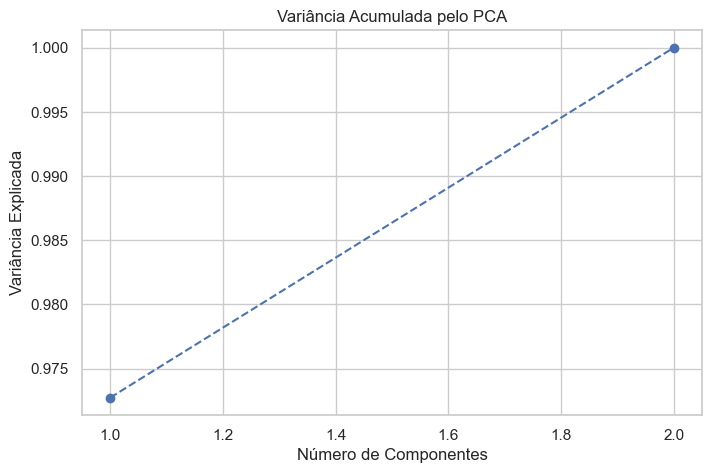

In [3]:
# Preparamos os dados agrupando por município
metrics = ['quantidade_aprovada', 'valor_aprovado']
df_municipios, data_scaled = multivariada.prepare_cluster_data('municipio_nome', metrics)

# Verificamos a variância (PCA)
multivariada.plot_pca_variance(data_scaled)

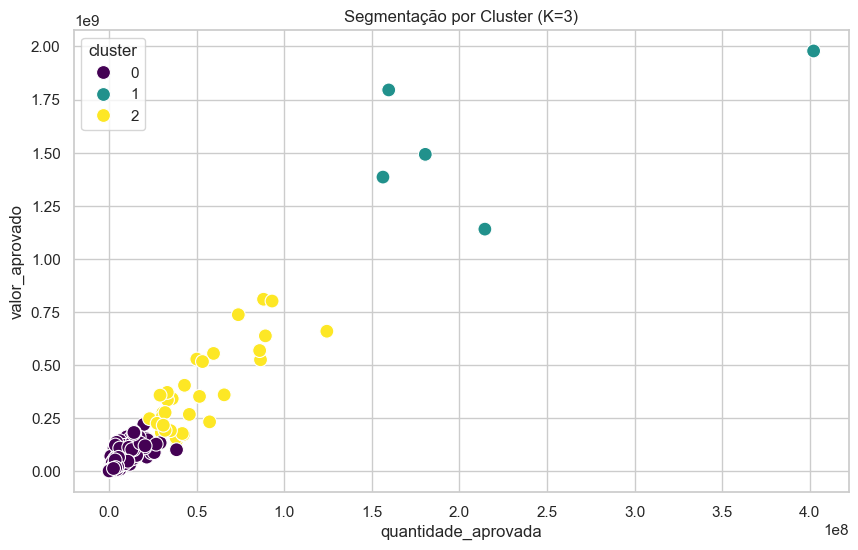

--- Amostra de Municípios por Cluster ---


,municipio_nome,quantidade_aprovada,valor_aprovado,cluster
2870,RIO DE JANEIRO,402204560,1.978698e+09,1
2946,SALVADOR,159653667,1.795034e+09,1
2801,RECIFE,180535288,1.491676e+09,1
402,BELO HORIZONTE,156364450,1.384595e+09,1
1231,FORTALEZA,214548217,1.139364e+09,1
1978,MANAUS,88190727,8.090423e+08,2
3268,SAO LUIS,93066334,8.005773e+08,2
393,BELEM,73779824,7.362569e+08,2
646,CAMPINAS,124335256,6.583306e+08,2
398,BELFORD ROXO,89243292,6.365533e+08,2


In [4]:
# Executamos o K-Means (ex: 3 clusters: Baixo, Médio e Alto custo/volume)
df_clusters = multivariada.run_kmeans(df_municipios, data_scaled, n_clusters=3)

# Exibindo os municípios de maior destaque em cada cluster
print("--- Amostra de Municípios por Cluster ---")
display(df_clusters.sort_values(by='valor_aprovado', ascending=False).head(15))

## 2. ANÁLISE DE PERFIL DOS CLUSTERS
**Objetivo:** Interpretar o que cada grupo representa.

In [5]:
perfil = df_clusters.groupby('cluster')[metrics].mean()
print("--- Perfil Médio dos Clusters ---")
display(perfil)

--- Perfil Médio dos Clusters ---


,quantidade_aprovada,valor_aprovado
cluster,,
0,9.002929e+05,6.217270e+06
1,2.226612e+08,1.557874e+09
2,5.020720e+07,3.722363e+08
